# CortexLab Tutorial: End-to-End Analysis with Synthetic Data

This notebook demonstrates a lightweight CortexLab analysis workflow using synthetic data only.

It follows the repository's documented analysis features and examples:
- brain-alignment benchmarking,
- cognitive load scoring,
- and a notebook-friendly temporal analysis extension.

No GPU or real fMRI data is required for this walkthrough.

## Sections
1. Setup
2. Brain Alignment
3. Cognitive Load
4. Temporal Dynamics
5. Connectivity
6. Modality Attribution
7. Summary

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from cortexlab.analysis import (
    BrainAlignmentBenchmark,
    CognitiveLoadScorer,
    TemporalDynamicsAnalyzer,
    ROIConnectivityAnalyzer,
)

plt.rcParams["figure.figsize"] = (7, 4)

print("Notebook environment ready!")

Notebook environment ready!


## 1. Setup

In this tutorial, we use synthetic arrays to mimic the shapes expected by CortexLab analysis tools.

We prepare:
- model features for brain-alignment benchmarking,
- synthetic brain predictions across vertices,
- and a small ROI dictionary for region-level summaries.

In [2]:
rng = np.random.default_rng(42)

# synthetic data for brain-alignment benchmarking
n_stimuli = 50
n_vertices = 500
n_timepoints = 30

model_features = rng.normal(size=(n_stimuli, 768))
brain_predictions = rng.normal(size=(n_stimuli, n_vertices))

roi_indices = {
    "V1": np.arange(0, 100),
    "MT": np.arange(100, 200),
    "A1": np.arange(200, 300),
    "Broca": np.arange(300, 400),
    "PFC": np.arange(400, 500),
}

# realistic synthetic time-series data for later sections
t = np.arange(n_timepoints)
stimulus = np.zeros(n_timepoints)
stimulus[[5, 15, 25]] = 1.0  # events at these TRs

hrf_t = np.arange(20)
hrf = hrf_t * np.exp(-hrf_t / 1.5)
hrf /= hrf.max()
bold = np.convolve(stimulus, hrf)[:n_timepoints]

predictions = rng.normal(size=(n_timepoints, n_vertices)) * 0.15
model_features_ts = np.zeros((n_timepoints, 3))
model_features_ts[:, 0] = bold
model_features_ts[:, 1] = np.roll(bold, 1)
model_features_ts[:, 2] = np.roll(bold, 2)

for v in roi_indices["V1"]:
    predictions[:, v] += bold * 1.0
for v in roi_indices["MT"]:
    predictions[:, v] += bold * 0.8
for v in roi_indices["A1"]:
    predictions[:, v] += bold * 0.3
for v in roi_indices["Broca"]:
    predictions[:, v] += np.roll(bold, 2) * 0.5
for v in roi_indices["PFC"]:
    predictions[:, v] += np.convolve(bold, np.ones(5) / 5, mode="same") * 0.4

print("model_features shape:", model_features.shape)
print("brain_predictions shape:", brain_predictions.shape)
print("predictions shape:", predictions.shape)
print("time-series model feature shape:", model_features_ts.shape)
print("ROIs:", list(roi_indices.keys()))

model_features shape: (50, 768)
brain_predictions shape: (50, 500)
predictions shape: (30, 500)
time-series model feature shape: (30, 3)
ROIs: ['V1', 'MT', 'A1', 'Broca', 'PFC']


## 2. Brain Alignment

CortexLab includes a brain-alignment benchmark that compares model features against predicted brain responses.

Following the repository example, we score one synthetic feature matrix against one synthetic brain-prediction matrix using multiple methods:
- RSA
- CKA
- Procrustes

In [3]:
# Initialize benchmark
bench = BrainAlignmentBenchmark(
    brain_predictions,
    roi_indices=roi_indices
)

print("BrainAlignmentBenchmark initialized successfully.")

BrainAlignmentBenchmark initialized successfully.


In [4]:
# Run benchmark
alignment_results = {}

for method in ["rsa", "cka", "procrustes"]:
    result = bench.score_model(model_features, method=method)
    alignment_results[method] = result

    print(f"{method.upper()} aggregate score: {result.aggregate_score:.4f}")
    for roi, score in result.roi_scores.items():
        print(f"  {roi}: {score:.4f}")
    print()

RSA aggregate score: 0.0129
  V1: 0.0356
  MT: -0.0024
  A1: -0.0119
  Broca: -0.0156
  PFC: 0.0166

CKA aggregate score: 0.9267
  V1: 0.8064
  MT: 0.8043
  A1: 0.7811
  Broca: 0.7851
  PFC: 0.7982

PROCRUSTES aggregate score: 0.7818
  V1: 0.5139
  MT: 0.5115
  A1: 0.5015
  Broca: 0.4977
  PFC: 0.5140



The benchmark returns one aggregate score and one score per ROI.

Because this notebook uses random synthetic inputs, the scores do not have neuroscientific meaning.  
They simply demonstrate the analysis interface and output format.

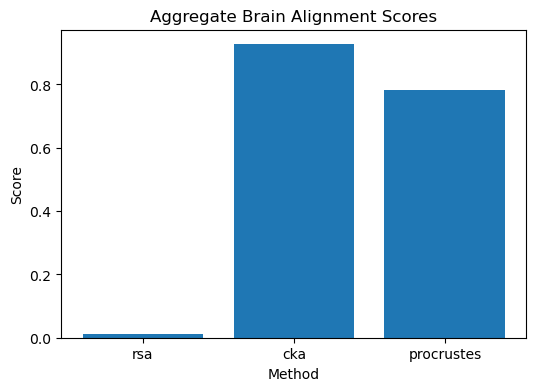

In [5]:
# Aggregate bar chart
methods = list(alignment_results.keys())
aggregate_scores = [alignment_results[m].aggregate_score for m in methods]

plt.figure(figsize=(6, 4))
plt.bar(methods, aggregate_scores)
plt.title("Aggregate Brain Alignment Scores")
plt.xlabel("Method")
plt.ylabel("Score")
plt.show()

### Permutation Test for Statistical Interpretation

To interpret whether an alignment score is larger than chance, we compare the real RSA score against a null distribution generated by shuffling the synthetic feature matrix.

In [6]:
# permutation test code
n_perm = 100
null_scores = []

for _ in range(n_perm):
    shuffled_features = rng.permutation(model_features, axis=0)
    shuffled_result = bench.score_model(shuffled_features, method="rsa")
    null_scores.append(shuffled_result.aggregate_score)

real_score = alignment_results["rsa"].aggregate_score

print("Real RSA score:", round(real_score, 4))
print("Mean null RSA score:", round(np.mean(null_scores), 4))

Real RSA score: 0.0129
Mean null RSA score: -0.0051


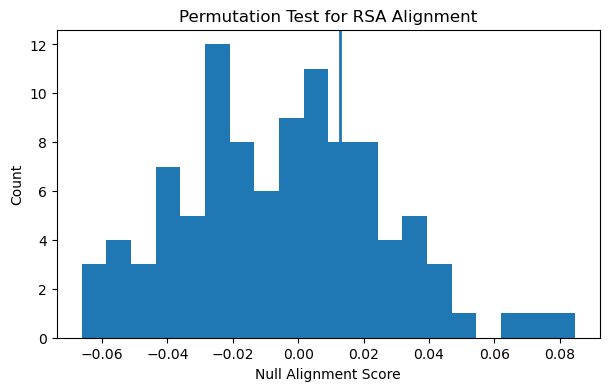

In [7]:
# permutation histogram
plt.figure(figsize=(7, 4))
plt.hist(null_scores, bins=20)
plt.axvline(real_score, linewidth=2)
plt.title("Permutation Test for RSA Alignment")
plt.xlabel("Null Alignment Score")
plt.ylabel("Count")
plt.show()

## 3. Cognitive Load

The repository example also includes a cognitive-load scorer.

Here we create synthetic time-varying predictions and use the scorer to estimate:
- overall load,
- visual complexity,
- auditory demand,
- language processing,
- executive load.

In [8]:
scorer = CognitiveLoadScorer(roi_indices, baseline_activation=0.5)
print("CognitiveLoadScorer initialized successfully.")


CognitiveLoadScorer initialized successfully.


In [9]:
# Reuse the realistic synthetic BOLD-style predictions created in Setup
print("Using HRF-convolved synthetic responses for cognitive-load scoring.")
print("predictions shape:", predictions.shape)


Using HRF-convolved synthetic responses for cognitive-load scoring.
predictions shape: (30, 500)


In [10]:
# Score predictions
load_result = scorer.score_predictions(predictions, tr_seconds=1.0)

print(f"Overall load: {load_result.overall_load:.2f}")
print(f"Visual complexity: {load_result.visual_complexity:.2f}")
print(f"Auditory demand: {load_result.auditory_demand:.2f}")
print(f"Language processing: {load_result.language_processing:.2f}")
print(f"Executive load: {load_result.executive_load:.2f}")
print(f"Timeline length: {len(load_result.timeline)}")


Overall load: 0.23
Visual complexity: 0.58
Auditory demand: 0.35
Language processing: 0.00
Executive load: 0.00
Timeline length: 30


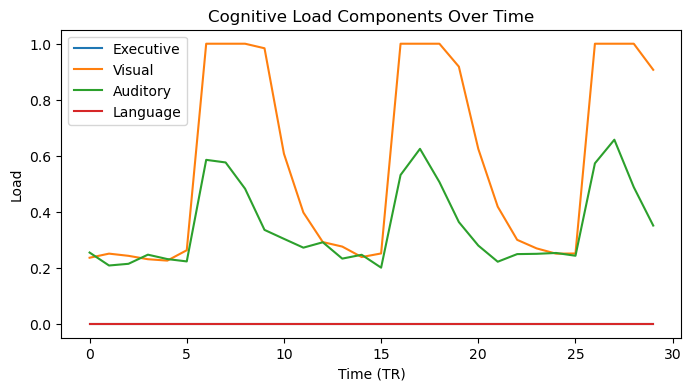

In [11]:
# extract timeline
time_axis = [t for t, _ in load_result.timeline]

# extract component loads
executive = [metrics["executive_load"] for _, metrics in load_result.timeline]
visual = [metrics["visual_complexity"] for _, metrics in load_result.timeline]
auditory = [metrics["auditory_demand"] for _, metrics in load_result.timeline]
language = [metrics["language_processing"] for _, metrics in load_result.timeline]

# plot components
plt.figure(figsize=(8, 4))
plt.plot(time_axis, executive, label="Executive")
plt.plot(time_axis, visual, label="Visual")
plt.plot(time_axis, auditory, label="Auditory")
plt.plot(time_axis, language, label="Language")

plt.title("Cognitive Load Components Over Time")
plt.xlabel("Time (TR)")
plt.ylabel("Load")
plt.legend()
plt.show()

In this synthetic example, the visual ROIs respond most strongly to the event-driven HRF signal, auditory activity is weaker, and later components appear in language and executive regions. Because the data are structured rather than pure Gaussian noise, the curves below look more like plausible BOLD-like responses and make the tutorial easier to interpret.

## 4. Temporal Dynamics

This section uses the built-in `TemporalDynamicsAnalyzer` instead of custom helper functions.  
That keeps the notebook shorter and demonstrates the CortexLab API that users would actually call in practice.

In [12]:
# Initialize analyzer and run temporal-dynamics analysis
temporal_analyzer = TemporalDynamicsAnalyzer(roi_indices, tr_seconds=1.0)
temporal_result = temporal_analyzer.analyze(predictions, model_features_ts)

print("Peak latencies:")
for roi_name, latency in temporal_result.peak_latencies.items():
    print(f"  {roi_name}: {latency}")


Peak latencies:
  V1: 17.0
  MT: 27.0
  A1: 27.0
  Broca: 8.0
  PFC: 8.0


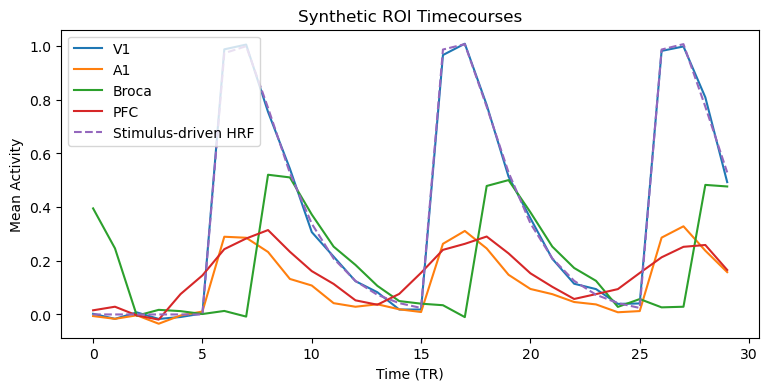

In [13]:
# Plot mean ROI timecourses from the realistic synthetic predictions
roi_names = ["V1", "A1", "Broca", "PFC"]
time_axis = np.arange(predictions.shape[0])

plt.figure(figsize=(9, 4))

for roi_name in roi_names:
    vertices = roi_indices[roi_name]
    tc = predictions[:, vertices].mean(axis=1)
    plt.plot(time_axis, tc, label=roi_name)

plt.plot(time_axis, bold, label="Stimulus-driven HRF", linestyle="--")
plt.title("Synthetic ROI Timecourses")
plt.xlabel("Time (TR)")
plt.ylabel("Mean Activity")
plt.legend()
plt.show()

In [14]:
# Peak summary
print("Temporal dynamics summary:")
for roi_name, latency in temporal_result.peak_latencies.items():
    print(f" {roi_name}: peak latency = {latency}")

Temporal dynamics summary:
 V1: peak latency = 17.0
 MT: peak latency = 27.0
 A1: peak latency = 27.0
 Broca: peak latency = 8.0
 PFC: peak latency = 8.0


Peak latency is reported directly by `TemporalDynamicsAnalyzer`. In this synthetic setup, early visual regions should peak earlier and more strongly, while higher-level regions can appear later or more sustained depending on how the synthetic response was constructed.

## 5. Connectivity

This section uses `ROIConnectivityAnalyzer` from the library rather than computing correlation, clustering, and graph metrics manually inside the notebook.

In [15]:
# Initialize connectivity analyzer
connectivity_analyzer = ROIConnectivityAnalyzer(roi_indices)


In [16]:
# Run connectivity analysis
connectivity_result = connectivity_analyzer.analyze(
    predictions,
    n_clusters=3,
    threshold=0.3,
)

print("Connectivity matrix shape:", connectivity_result.correlation_matrix.shape)

if hasattr(connectivity_result, "clusters"):
    print("\nClusters:")
    print(connectivity_result.clusters)

if hasattr(connectivity_result, "graph_metrics"):
    print("\nGraph metrics:")
    print(connectivity_result.graph_metrics)

Connectivity matrix shape: (5, 5)

Clusters:
{1: ['V1', 'MT', 'A1'], 3: ['Broca'], 2: ['PFC']}

Graph metrics:
{'degree_centrality': {'V1': 0.75, 'MT': 0.75, 'A1': 0.75, 'Broca': 0.0, 'PFC': 0.75}, 'mean_degree': 0.6}


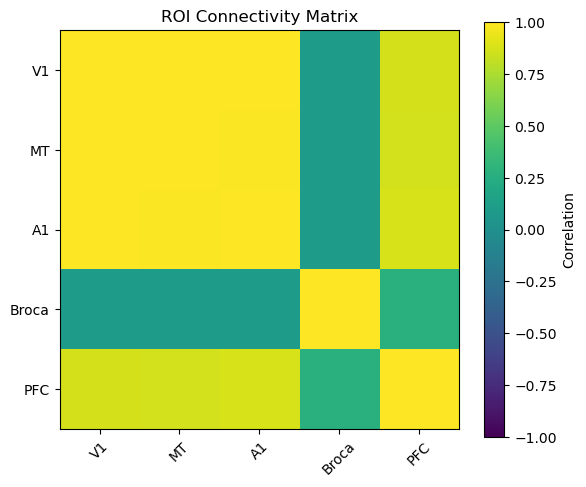

In [17]:
# Plot correlation matrix
corr_matrix = connectivity_result.correlation_matrix

plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix, vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(roi_indices)), list(roi_indices.keys()), rotation=45)
plt.yticks(range(len(roi_indices)), list(roi_indices.keys()))
plt.title("ROI Connectivity Matrix")
plt.tight_layout()
plt.show()


The matrix summarizes pairwise similarity between ROI timecourses derived from the realistic synthetic responses. Because V1 and MT share the strongest event-driven signal, they should typically appear more correlated than weakly driven or delayed regions.

In [18]:
if hasattr(connectivity_result, "clusters"):
    print("Functional ROI clusters:")
    for cid, members in connectivity_result.clusters.items():
        print(f"  Cluster {cid}: {members}")
else:
    print("Cluster output not available in this result object.")


Functional ROI clusters:
  Cluster 1: ['V1', 'MT', 'A1']
  Cluster 3: ['Broca']
  Cluster 2: ['PFC']


The clustering step groups ROIs using the analyzer's built-in logic, and optional graph metrics summarize which regions are most connected above the chosen threshold.

## 6. Modality Attribution

CortexLab also supports modality attribution for interpreting which input modality contributes most to predicted brain activity.

A full example needs a loaded model, so below we show the intended API pattern rather than a complete runnable synthetic demo:


In [19]:
# Example API pattern for modality attribution.
# A full runnable example requires a loaded trained model.

from cortexlab.inference.attribution import ModalityAttributor
# model = ...
# attributor = ModalityAttributor(model)
# attribution_result = attributor.attribute(batch)
# print(attribution_result)

This keeps the section concrete and points users toward the actual library entry point without leaving the tutorial as an empty placeholder.

## 7. Summary

This tutorial demonstrates the core **CortexLab analysis API workflow** for multimodal fMRI research.

Key API takeaways:

- `BrainAlignmentBenchmark` compares learned model features against brain-prediction targets across ROIs.
- `CognitiveLoadScorer` summarizes time-varying neural demand signals from predicted activity.
- `TemporalDynamicsAnalyzer` extracts interpretable temporal properties such as ROI peak latencies.
- `ROIConnectivityAnalyzer` computes ROI-level connectivity matrices, clustering structure, and graph summaries.
- `ModalityAttributor` provides the entry point for interpreting modality-specific contributions once a trained model is available.

Together, these analyzers form a reusable workflow for:
1. validating encoding quality,
2. characterizing temporal response structure,
3. analyzing functional connectivity,
4. interpreting multimodal model contributions.

Because the synthetic data use HRF-shaped responses, the examples are also closer to realistic hemodynamic signals users may encounter in practice.